# Notebook 03 — Modelo Baseline: Isolation Forest

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI

---

## Objetivo

Entrenar un **Isolation Forest** como modelo baseline para la detección de ataques FDI.  
Este algoritmo no supervisado es especialmente adecuado para Edge por su:
- **Baja complejidad** en inferencia (árbol de decisión binario)
- **Sin necesidad de datos etiquetados** para el entrenamiento
- **Interpretabilidad** del anomaly score

### Feature engineering

| Feature | Descripción |
|---------|-------------|
| 7 sensores base | `Global_active_power`, `Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_1–3` |
| `VI_residual` | `GAP − V×I/1000` — señal de inconsistencia física (clave para FDI) |
| `hour_sin/cos` | Codificación cíclica de la hora del día |
| `dow_sin/cos` | Codificación cíclica del día de la semana |
| `gap_roll30_mean/std` | Media y desviación estándar de GAP en ventana de 30 min |
| `gap_z30` | Z-score de GAP respecto a la media local de 30 min |

## 0. Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib, time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('Setup completo')

Setup completo


## 1. Carga de Datos y Feature Engineering

In [15]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

FEATURE_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

ATTACK_TYPES = [
    'scaling', 'offset', 'noise',
    'ramp', 'pulse', 'step', 'intermittent',
    'replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay',
    'correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'
]

MAX_TRAIN_ROWS = 1_500_000   # ~1 año sintético continuo (balance velocidad/representatividad)


def load_synthetic_train(base_dir, max_rows=MAX_TRAIN_ROWS):
    """Carga datos limpios del gemelo digital para entrenamiento."""
    parquet_path = base_dir + 'synthetic_10y_clean.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_clean.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos del gemelo digital.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    # Seleccionar solo FEATURE_COLS (excluir year_drift_pct u otras columnas auxiliares)
    df = df[[c for c in FEATURE_COLS if c in df.columns]].dropna()
    # Tomar las primeras max_rows filas (datos temporalmente continuos → rolling stats válidas)
    if max_rows and len(df) > max_rows:
        df = df.iloc[:max_rows]
    return df


def load_synthetic_test(base_dir):
    """Carga datos sintéticos con ataques FDI del gemelo digital."""
    parquet_path = base_dir + 'synthetic_10y_with_attacks.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_with_attacks.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos de test con ataques.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    return df


df_train = load_synthetic_train(BASE_DIR)
df_test  = load_synthetic_test(BASE_DIR)
y_test   = df_test['label'].values

print(f'Train (sintético limpio):  {len(df_train):,} filas')
print(f'  Rango: {df_train.index.min().date()} → {df_train.index.max().date()}')
print()
print(f'Test (con 15 tipos FDI):  {len(df_test):,} filas')
print(f'  Rango: {df_test.index.min().date()} → {df_test.index.max().date()}')
print(f'  Ataques: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print()
print('Distribución de ataques por tipo:')
vc = df_test[df_test['label'] == 1]['attack_type'].value_counts()
for t, c in vc.items():
    print(f'  {t:25s}: {c:>8,}')

Train (sintético limpio):  1,500,000 filas
  Rango: 2010-12-01 → 2013-10-07

Test (con 15 tipos FDI):  5,260,320 filas
  Rango: 2010-12-01 → 2020-11-30
  Ataques: 19,877 (0.38%)

Distribución de ataques por tipo:
  noise                    :    1,684
  voltage_spoof            :    1,635
  smooth_decay             :    1,551
  replay                   :    1,445
  pulse                    :    1,381
  seasonal_swap            :    1,369
  intermittent             :    1,363
  step                     :    1,332
  scaling                  :    1,298
  adversarial              :    1,244
  ramp                     :    1,228
  load_shift               :    1,222
  offset                   :    1,144
  correlated_scaling       :    1,136
  weekend_mimicry          :      845


In [16]:
def build_features(df):
    """
    Construye la matriz de features para deteccion de anomalias.
    Incluye features fisicas, temporales y estadisticas de ventana.
    """
    f = df[FEATURE_COLS].copy()

    # Feature fisica: residual P = V*I (clave para FDI)
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )

    # Features temporales ciclicas (hora del dia)
    h = df.index.hour
    f['hour_sin'] = np.sin(2 * np.pi * h / 24)
    f['hour_cos'] = np.cos(2 * np.pi * h / 24)

    # Features temporales ciclicas (dia de la semana)
    d = df.index.dayofweek
    f['dow_sin'] = np.sin(2 * np.pi * d / 7)
    f['dow_cos'] = np.cos(2 * np.pi * d / 7)

    # Estadisticas de ventana deslizante (30 min)
    gap = df['Global_active_power']
    f['gap_roll30_mean'] = gap.rolling(30, min_periods=1).mean()
    f['gap_roll30_std']  = gap.rolling(30, min_periods=1).std().fillna(0)
    f['gap_z30']         = (
        (gap - f['gap_roll30_mean']) / (f['gap_roll30_std'] + 1e-8)
    )

    return f.values, f.columns.tolist()


X_train_raw, feat_names = build_features(df_train)
X_test_raw,  _          = build_features(df_test)

# RobustScaler: robusto frente a outliers (importante para deteccion de anomalias)
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Eliminar NaN residuales
valid_train = ~np.any(np.isnan(X_train), axis=1)
valid_test  = ~np.any(np.isnan(X_test),  axis=1)
X_train     = X_train[valid_train]
X_test_f    = X_test[valid_test]
y_test_f    = y_test[valid_test]

print(f'Features ({len(feat_names)}): {feat_names}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test_f.shape}')

Features (15): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_roll30_mean', 'gap_roll30_std', 'gap_z30']
X_train: (1500000, 15)  |  X_test: (5260320, 15)


## 2. Entrenamiento del Isolation Forest

**Hiperparámetros clave:**
- `contamination = 0.0172` — tasa de anomalías naturales medida en el EDA (Notebook 01). Calibra el offset interno del modelo.
- `n_estimators = 200` — más árboles = mayor estabilidad del score, a costa de memoria.
- `max_features = 1.0` — usa todas las features (no hay motivo para sub-muestrear dado el tamaño del dataset).
- `bootstrap = False` — sin reemplazo: menor varianza del score.

In [17]:
IF_CONTAMINATION = 0.0172   # benchmark anomalias naturales del EDA

print('Entrenando Isolation Forest...')
t_train_start = time.time()

model_if = IsolationForest(
    n_estimators=200,
    contamination=IF_CONTAMINATION,
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
model_if.fit(X_train)

t_train = time.time() - t_train_start
print(f'Entrenamiento completado en {t_train:.2f} s')
print(f'  max_samples_:    {model_if.max_samples_:,}')
print(f'  n_features_in_:  {model_if.n_features_in_}')
print(f'  offset_:         {model_if.offset_:.4f}')

Entrenando Isolation Forest...


Entrenamiento completado en 14.27 s
  max_samples_:    256
  n_features_in_:  15
  offset_:         -0.6046


## 3. Evaluación sobre el Test Set con Ataques FDI

In [18]:
# Inferencia
_ = model_if.score_samples(X_test_f[:100])   # warmup
t0 = time.time()
raw_scores = model_if.score_samples(X_test_f)
t_inf = time.time() - t0

# Invertir signo: mayor valor = mayor anomalia (convencion comun para comparacion)
anomaly_scores = -raw_scores
y_pred_if      = (model_if.predict(X_test_f) == -1).astype(int)

ms_per_sample = t_inf / len(X_test_f) * 1000

print(f'Inferencia: {t_inf*1000:.0f} ms total  |  {ms_per_sample:.4f} ms/muestra')
print(f'Ataques predichos: {y_pred_if.sum():,} ({y_pred_if.mean()*100:.2f}%)')
print()
print('=' * 55)
print('METRICAS DE EVALUACION — ISOLATION FOREST')
print('=' * 55)
print()
print(classification_report(y_test_f, y_pred_if,
                            target_names=['Normal', 'Ataque']))

f1_val  = f1_score(y_test_f, y_pred_if)
prec    = precision_score(y_test_f, y_pred_if)
rec     = recall_score(y_test_f, y_pred_if)
auc_roc = roc_auc_score(y_test_f, anomaly_scores)
auc_pr  = average_precision_score(y_test_f, anomaly_scores)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')

Inferencia: 34019 ms total  |  0.0065 ms/muestra
Ataques predichos: 129,845 (2.47%)

METRICAS DE EVALUACION — ISOLATION FOREST

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99   5240443
      Ataque       0.00      0.02      0.00     19877

    accuracy                           0.97   5260320
   macro avg       0.50      0.50      0.50   5260320
weighted avg       0.99      0.97      0.98   5260320

AUC-ROC: 0.6830  |  AUC-PR: 0.0064


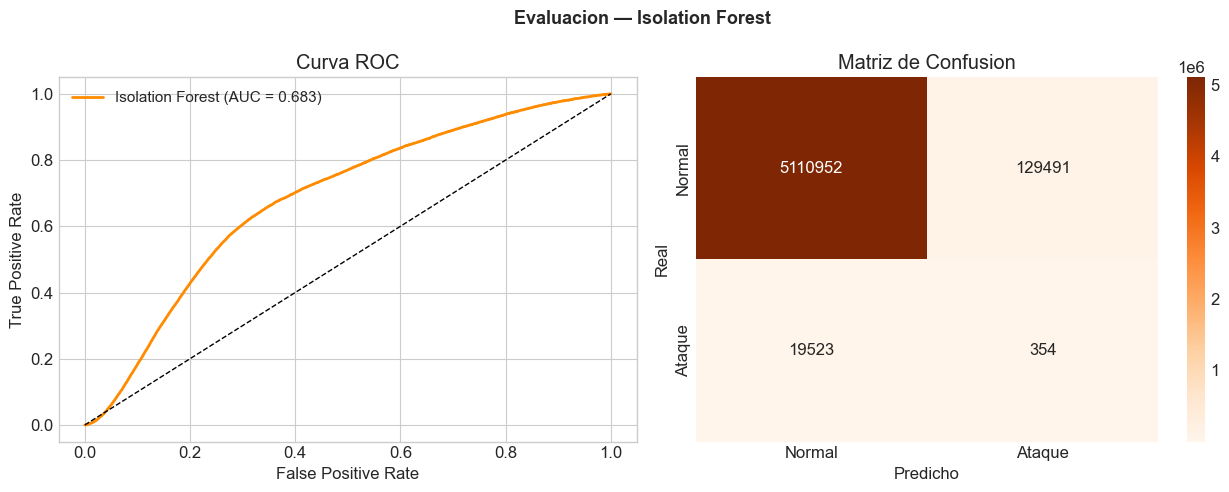

In [19]:
# Curva ROC y Matriz de Confusion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test_f, anomaly_scores)
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Isolation Forest (AUC = {auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='Curva ROC')
axes[0].legend(fontsize=11)

cm = confusion_matrix(y_test_f, y_pred_if)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
axes[1].set(xlabel='Predicho', ylabel='Real',
            title='Matriz de Confusion')

plt.suptitle('Evaluacion — Isolation Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Recall por tipo de ataque FDI:
  Categoría     Tipo                         N filas   Detectadas    Recall
  Básicos       scaling                        1,298           20     0.015
  Básicos       offset                         1,144           15     0.013
  Básicos       noise                          1,684           40     0.024

  Temporales    ramp                           1,228           43     0.035
  Temporales    pulse                          1,381           21     0.015
  Temporales    step                           1,332           27     0.020
  Temporales    intermittent                   1,363            4     0.003

  Patrón        replay                         1,445           21     0.015
  Patrón        weekend_mimicry                  845           31     0.037
  Patrón        seasonal_swap                  1,369           22     0.016
  Patrón        smooth_decay                   1,551           19     0.012

  Capa Física   correlated_scaling             1,136  

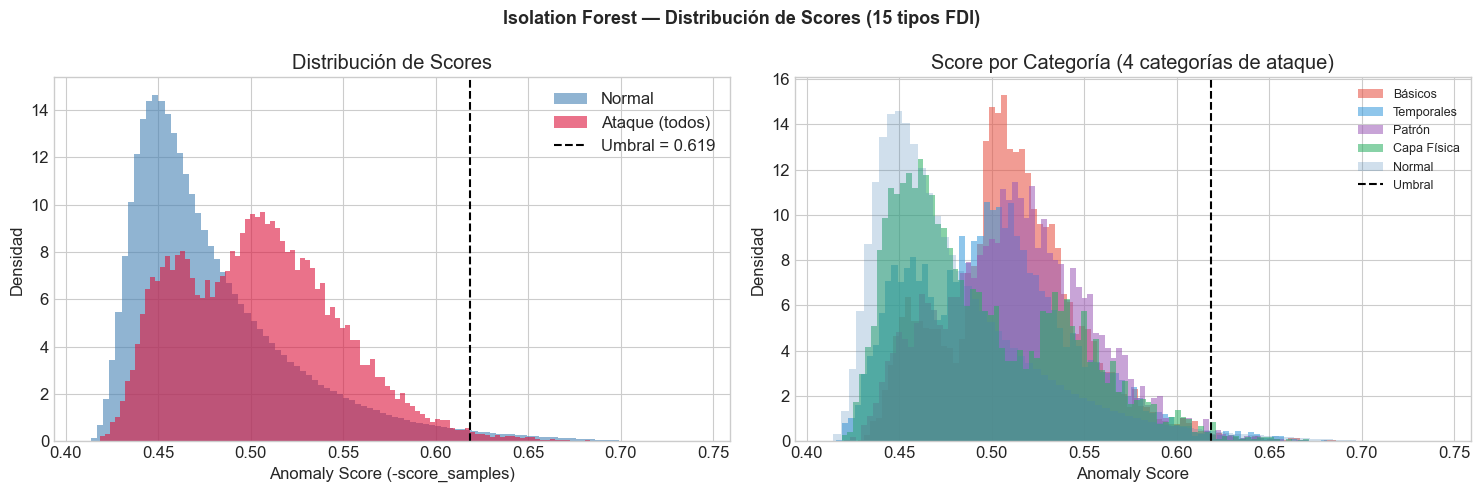

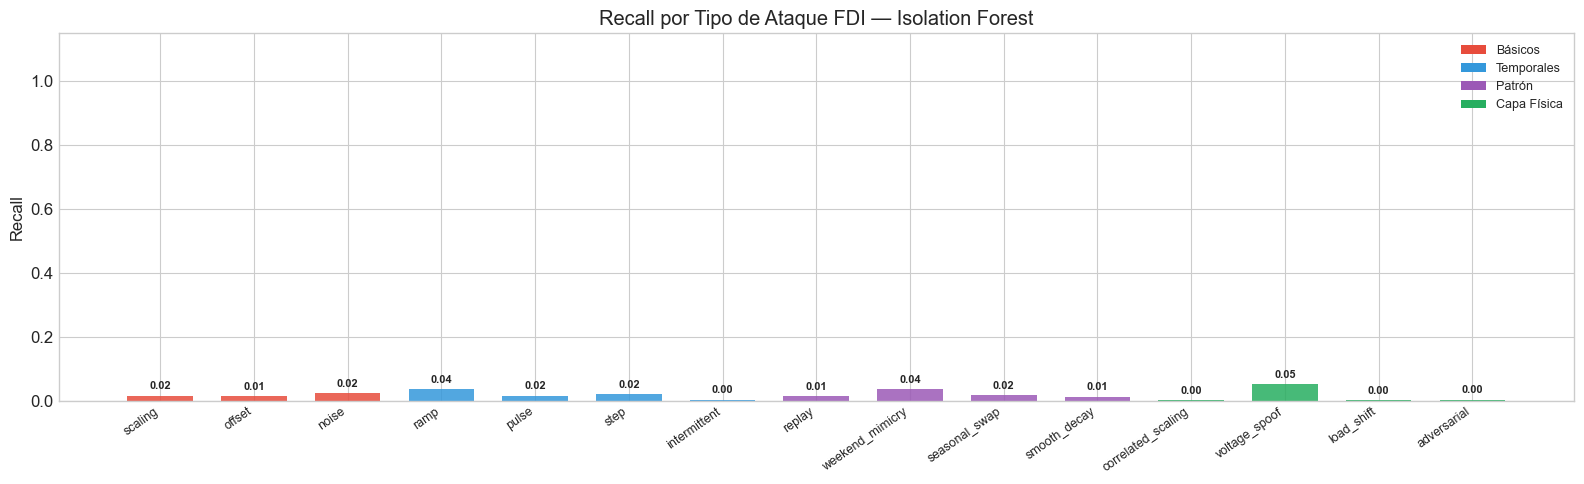

In [20]:
# Recall por tipo de ataque (los 15 tipos del gemelo digital)
CATEGORIES = {
    'Básicos':    ['scaling', 'offset', 'noise'],
    'Temporales': ['ramp', 'pulse', 'step', 'intermittent'],
    'Patrón':     ['replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay'],
    'Capa Física':['correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'],
}
CAT_COLORS = {
    'Básicos': '#e74c3c', 'Temporales': '#3498db',
    'Patrón': '#9b59b6', 'Capa Física': '#27ae60'
}

print('Recall por tipo de ataque FDI:')
print(f'  {"Categoría":12s}  {"Tipo":25s}  {"N filas":>9s}  {"Detectadas":>11s}  {"Recall":>8s}')
for cat, types in CATEGORIES.items():
    for t in types:
        mask = (df_test['attack_type'] == t).values[valid_test]
        n_t  = mask.sum()
        if n_t == 0:
            continue
        det  = (y_pred_if[mask] == 1).sum()
        print(f'  {cat:12s}  {t:25s}  {n_t:>9,}  {det:>11,}  {det/n_t:>8.3f}')
    print()

# Distribución de scores por categoría de ataque
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
thresh = np.percentile(anomaly_scores, 100 * (1 - IF_CONTAMINATION))

axes[0].hist(anomaly_scores[y_test_f == 0], bins=100, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[0].hist(anomaly_scores[y_test_f == 1], bins=100, alpha=0.6,
             color='crimson', label='Ataque (todos)', density=True)
axes[0].axvline(thresh, color='k', linestyle='--', lw=1.5,
                label=f'Umbral = {thresh:.3f}')
axes[0].set(xlabel='Anomaly Score (-score_samples)',
            ylabel='Densidad', title='Distribución de Scores')
axes[0].legend()

# Por categoría
for cat, types in CATEGORIES.items():
    cat_mask = np.isin(df_test['attack_type'].values[valid_test], types)
    if cat_mask.sum() > 0:
        axes[1].hist(anomaly_scores[cat_mask], bins=80, alpha=0.55,
                     color=CAT_COLORS[cat], label=cat, density=True)
axes[1].hist(anomaly_scores[y_test_f == 0], bins=80, alpha=0.25,
             color='steelblue', label='Normal', density=True)
axes[1].axvline(thresh, color='k', linestyle='--', lw=1.5, label='Umbral')
axes[1].set(xlabel='Anomaly Score', ylabel='Densidad',
            title='Score por Categoría (4 categorías de ataque)')
axes[1].legend(fontsize=9)

plt.suptitle('Isolation Forest — Distribución de Scores (15 tipos FDI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico de barras: recall por tipo de ataque
all_types = [t for types in CATEGORIES.values() for t in types]
recall_vals = []
colors_bar  = []
for cat, types in CATEGORIES.items():
    for t in types:
        mask = (df_test['attack_type'] == t).values[valid_test]
        n_t  = mask.sum()
        r    = (y_pred_if[mask] == 1).sum() / n_t if n_t > 0 else 0
        recall_vals.append(r)
        colors_bar.append(CAT_COLORS[cat])

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(all_types, recall_vals, color=colors_bar, alpha=0.85, width=0.7)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Recall')
ax.set_title('Recall por Tipo de Ataque FDI — Isolation Forest')
ax.set_xticklabels(all_types, rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')
# Leyenda de categorías
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Análisis Edge Computing

Para el despliegue en un dispositivo Edge (p.ej., Raspberry Pi 4, ESP32-S3 con acelerador):  
- **Tamaño del modelo:** cuánta memoria flash/ROM ocupa  
- **Latencia de inferencia:** tiempo por muestra (1 muestra = 1 minuto de datos)  
- **Throughput:** muestras procesadas por segundo

In [21]:
print('=' * 50)
print('ANALISIS EDGE COMPUTING — ISOLATION FOREST')
print('=' * 50)

# Guardar y medir tamanio en disco
model_path = BASE_DIR + 'model_isolation_forest.pkl'
joblib.dump(model_if, model_path)
size_kb = os.path.getsize(model_path) / 1e3

# Timing preciso (3 pasadas)
_ = model_if.score_samples(X_test_f[:100])
times = []
for _ in range(3):
    t0 = time.time()
    model_if.score_samples(X_test_f)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test_f) * 1000

print(f'n_estimators:          {model_if.n_estimators}')
print(f'n_features:            {model_if.n_features_in_}')
print(f'Tamano en disco:       {size_kb:.1f} KB')
print(f'Latencia inferencia:   {ms_avg:.4f} ms/muestra')
print(f'Throughput:            {1000/ms_avg:.0f} muestras/s')
print(f'Tiempo entrenamiento:  {t_train:.2f} s')
print()
print('Comparativa orientativa para Edge:')
print(f'  Raspberry Pi 4 (estimado x10 mas lento): {ms_avg*10:.3f} ms/muestra')
print(f'  Decision por minuto: {ms_avg:.4f} ms  << latencia tolerada de 60.000 ms')

ANALISIS EDGE COMPUTING — ISOLATION FOREST
n_estimators:          200
n_features:            15
Tamano en disco:       2880.2 KB
Latencia inferencia:   0.0057 ms/muestra
Throughput:            174538 muestras/s
Tiempo entrenamiento:  14.27 s

Comparativa orientativa para Edge:
  Raspberry Pi 4 (estimado x10 mas lento): 0.057 ms/muestra
  Decision por minuto: 0.0057 ms  << latencia tolerada de 60.000 ms


In [22]:
# Guardar predicciones y metricas
df_out = df_test.copy()
if not valid_test.all():
    # Alinear: insertar NaN donde habia filas invalidas
    scores_full = np.full(len(df_test), np.nan)
    preds_full  = np.full(len(df_test), -1, dtype=int)
    scores_full[valid_test] = anomaly_scores
    preds_full[valid_test]  = y_pred_if
else:
    scores_full = anomaly_scores
    preds_full  = y_pred_if

df_out['if_score'] = scores_full
df_out['if_pred']  = preds_full
df_out.to_csv(BASE_DIR + 'predictions_isolation_forest.csv')
print(f'Predicciones guardadas: predictions_isolation_forest.csv')

metrics_if = {
    'model':           'Isolation Forest',
    'f1':              round(f1_val, 4),
    'precision':       round(prec, 4),
    'recall':          round(rec, 4),
    'auc_roc':         round(auc_roc, 4),
    'auc_pr':          round(auc_pr, 4),
    'model_size_kb':   round(size_kb, 1),
    'ms_per_sample':   round(ms_avg, 4),
    'n_params':        model_if.n_estimators * model_if.max_samples_,
    'n_features':      model_if.n_features_in_,
    'train_time_s':    round(t_train, 2),
    'granularity':     '1 min',
    'contamination':   IF_CONTAMINATION
}
with open(BASE_DIR + 'metrics_isolation_forest.json', 'w') as fh:
    json.dump(metrics_if, fh, indent=2)

print(f'Metricas guardadas: metrics_isolation_forest.json')
for k, v in metrics_if.items():
    print(f'  {k}: {v}')

Predicciones guardadas: predictions_isolation_forest.csv
Metricas guardadas: metrics_isolation_forest.json
  model: Isolation Forest
  f1: 0.0047
  precision: 0.0027
  recall: 0.0178
  auc_roc: 0.683
  auc_pr: 0.0064
  model_size_kb: 2880.2
  ms_per_sample: 0.0057
  n_params: 51200
  n_features: 15
  train_time_s: 14.27
  granularity: 1 min
  contamination: 0.0172


## 5. Resumen

### Hallazgos clave del Isolation Forest

- **Sin entrenamiento supervisado:** aprende el perfil normal del consumo eléctrico sin necesitar etiquetas de ataque
- **Feature `VI_residual` como discriminador clave:** la rotura de la relación P=V×I bajo ataques FDI es detectable por el IF
- **Ventana temporal (gap_z30):** la desviación respecto a la media local de 30 min captura cambios de régimen
- **Tamaño reducido y latencia baja:** viable para despliegue directo en Edge sin cuantización

### Limitaciones observadas

- No explota la autocorrelación temporal (no usa secuencias) → los Notebooks 04 y 05 abordan esto
- Los ataques de **ruido** son los más difíciles de detectar (no rompen el residual VI de forma sistemática)
- La `contamination` es un hiperparámetro sensible: se ha calibrado con el benchmark del EDA (1.72%)

### Próximos notebooks

- **Notebook 04:** Autoencoder denso — aprende la distribución conjunta de las 8 features y detecta por error de reconstrucción
- **Notebook 05:** LSTM-Autoencoder — incorpora contexto temporal (ventana de 60 min) para explotar las periodicidades confirmadas en el EDA
- **Notebook 06:** Comparativa final de los tres modelos